# 1d spatiotemporal bilateral filtering

In [11]:
from pathlib import Path
import sys

import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np

folder = Path.cwd()
if not (folder / 'filters.py').exists():
    folder = folder / '1d_signal'
sys.path.insert(0, str(folder))

from filters import cross_bilateral_filter, laplacian_smoothing_filter
from optimizers import adam_optimizer, spatiotemporal_optimizer

plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'axes.grid': False,
    'font.size': 9,
    'axes.titlesize': 9,
    'axes.labelsize': 8,
    'legend.fontsize': 8,
})

rng = np.random.default_rng(4)

In [12]:
def make_paper_style_target(size):
    '''make a 1d piecewise smooth signal close to the paper examples.'''
    x = np.linspace(0, 1, size)
    target = np.zeros(size)

    plateau = (x >= 0.20) & (x < 0.34)
    bend = (x >= 0.34) & (x < 0.54)
    tail = x >= 0.54

    target[plateau] = 0.86
    bend_x = (x[bend] - 0.34) / 0.20
    target[bend] = 0.86 - 0.50 * bend_x - 0.18 * bend_x ** 2
    tail_x = (x[tail] - 0.54) / 0.46
    target[tail] = -0.62 + 1.42 * tail_x ** 2

    return target


def run_optimizer(optimizer, theta_start, gradient_fn, iterations, snapshots):
    '''run an optimizer and keep signal snapshots.'''
    theta = theta_start.copy()
    history = {0: theta.copy()}

    for iteration in range(1, iterations + 1):
        gradient = gradient_fn(theta, iteration - 1)
        theta = optimizer.step(theta, gradient)

        if iteration in snapshots:
            history[iteration] = theta.copy()

    return history


def run_gradient_descent(theta_start, gradient_fn, learning_rate, iterations, snapshots):
    '''run plain gradient descent and keep signal snapshots.'''
    theta = theta_start.copy()
    history = {0: theta.copy()}

    for iteration in range(1, iterations + 1):
        theta = theta - learning_rate * gradient_fn(theta, iteration - 1)

        if iteration in snapshots:
            history[iteration] = theta.copy()

    return history


def plot_target(target):
    '''plot the target parameter function by itself.'''
    figure, axis = plt.subplots(figsize=(7.4, 2.8), layout='constrained')
    axis.plot(target, color='#f5a400', linewidth=2.2)
    axis.axhline(0, color='#2ca25f', linewidth=0.8, alpha=0.65)
    axis.set_title('reference', fontsize=13, pad=10)
    axis.set_xticks([])
    axis.set_yticks([])
    axis.set_ylim(-0.85, 1.05)
    return figure


def plot_iteration_overlays(histories, target, snapshots, title):
    '''plot method panels like the paper, with iterations overlaid per method.'''
    iteration_colors = {
        0: '#1a9850',
        5: '#4575b4',
        50: '#8066ff',
        250: '#d33682',
        500: '#ff5f2e',
        1000: '#f5a400',
    }
    method_titles = {
        'gradient descent': '(a) gradient descent',
        'adam': '(b) adam',
        'laplacian': '(c) low-pass filter\n(laplacian smoothing)',
        'cross bilateral': '(d) cross-bilateral filter',
    }

    names = list(histories)
    figure = plt.figure(figsize=(13.4, 4.35), layout='constrained')
    grid = figure.add_gridspec(2, len(names) + 1, height_ratios=[1.0, 0.16])
    axes = []
    for column in range(len(names) + 1):
        share_axis = axes[0] if axes else None
        axes.append(figure.add_subplot(grid[0, column], sharey=share_axis))
    legend_axis = figure.add_subplot(grid[1, :])
    legend_axis.axis('off')
    x = np.arange(len(target))

    for axis, name in zip(axes[:-1], names):
        for iteration in snapshots:
            width = 1.0 if iteration not in (0, snapshots[-1]) else 1.35
            axis.plot(x, histories[name][iteration], color=iteration_colors[iteration], linewidth=width)

        axis.axhline(0, color='#2ca25f', linewidth=0.8, alpha=0.65)
        axis.set_title(method_titles[name], fontsize=11, pad=10)
        axis.set_xticks([])
        axis.set_yticks([])
        axis.set_ylim(-0.90, 1.10)

    axes[-1].plot(x, target, color='#f5a400', linewidth=2.0)
    axes[-1].axhline(0, color='#2ca25f', linewidth=0.8, alpha=0.65)
    axes[-1].set_title('(e) reference', fontsize=11, pad=10)
    axes[-1].set_xticks([])
    axes[-1].set_yticks([])
    axes[-1].set_ylim(-0.90, 1.10)

    handles = [Line2D([0], [0], color=iteration_colors[i], lw=1.8, label=str(i)) for i in snapshots]
    legend = legend_axis.legend(handles=handles, title='iteration:', loc='center', ncol=len(snapshots), frameon=False)
    legend.get_title().set_fontsize(10)
    for text in legend.get_texts():
        text.set_fontsize(10)
    figure.suptitle(title, fontsize=14)
    return figure

## figure 2 style: anisotropic objective

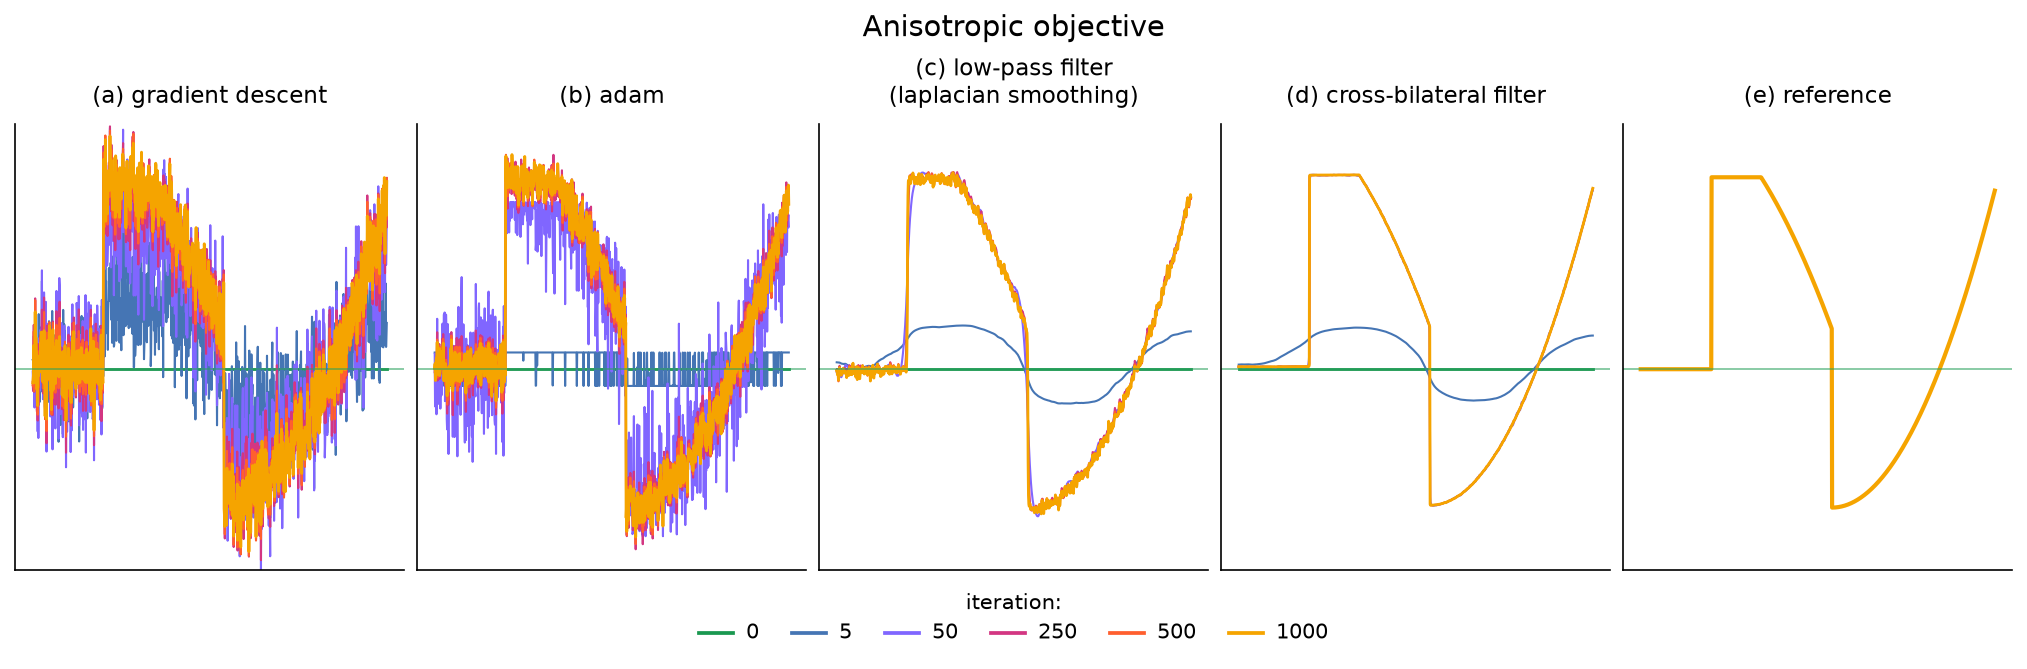

In [13]:
size = 1000
iterations = 1000
snapshots = [0, 5, 50, 250, 500, 1000]

target = make_paper_style_target(size)
theta_start = np.zeros(size)
a = rng.normal(size=(size, size))
ata = a.T @ a


def anisotropic_gradient(theta, iteration):
    '''gradient of (theta - target)^t A^t A (theta - target).'''
    return 2 * ata @ (theta - target)


laplacian = laplacian_smoothing_filter(strength=800.0)
bilateral = cross_bilateral_filter(sigma_spatial=70.0, sigma_data=0.10)

histories_figure_2 = {
    'gradient descent': run_gradient_descent(theta_start, anisotropic_gradient, 0.00005, iterations, snapshots),
    'adam': run_optimizer(adam_optimizer(lr=0.015, b_1=0.2, b_2=0.2), theta_start, anisotropic_gradient, iterations, snapshots),
    'laplacian': run_optimizer(spatiotemporal_optimizer(lr=0.045, filter=laplacian, b_1=0.2, b_2=0.2), theta_start, anisotropic_gradient, iterations, snapshots),
    'cross bilateral': run_optimizer(spatiotemporal_optimizer(lr=0.045, filter=bilateral, b_1=0.2, b_2=0.2), theta_start, anisotropic_gradient, iterations, snapshots),
}

plot_iteration_overlays(histories_figure_2, target, snapshots, 'Anisotropic objective');

## figure 3 style: isotropic objective 

f(theta) = ||theta - target||^2

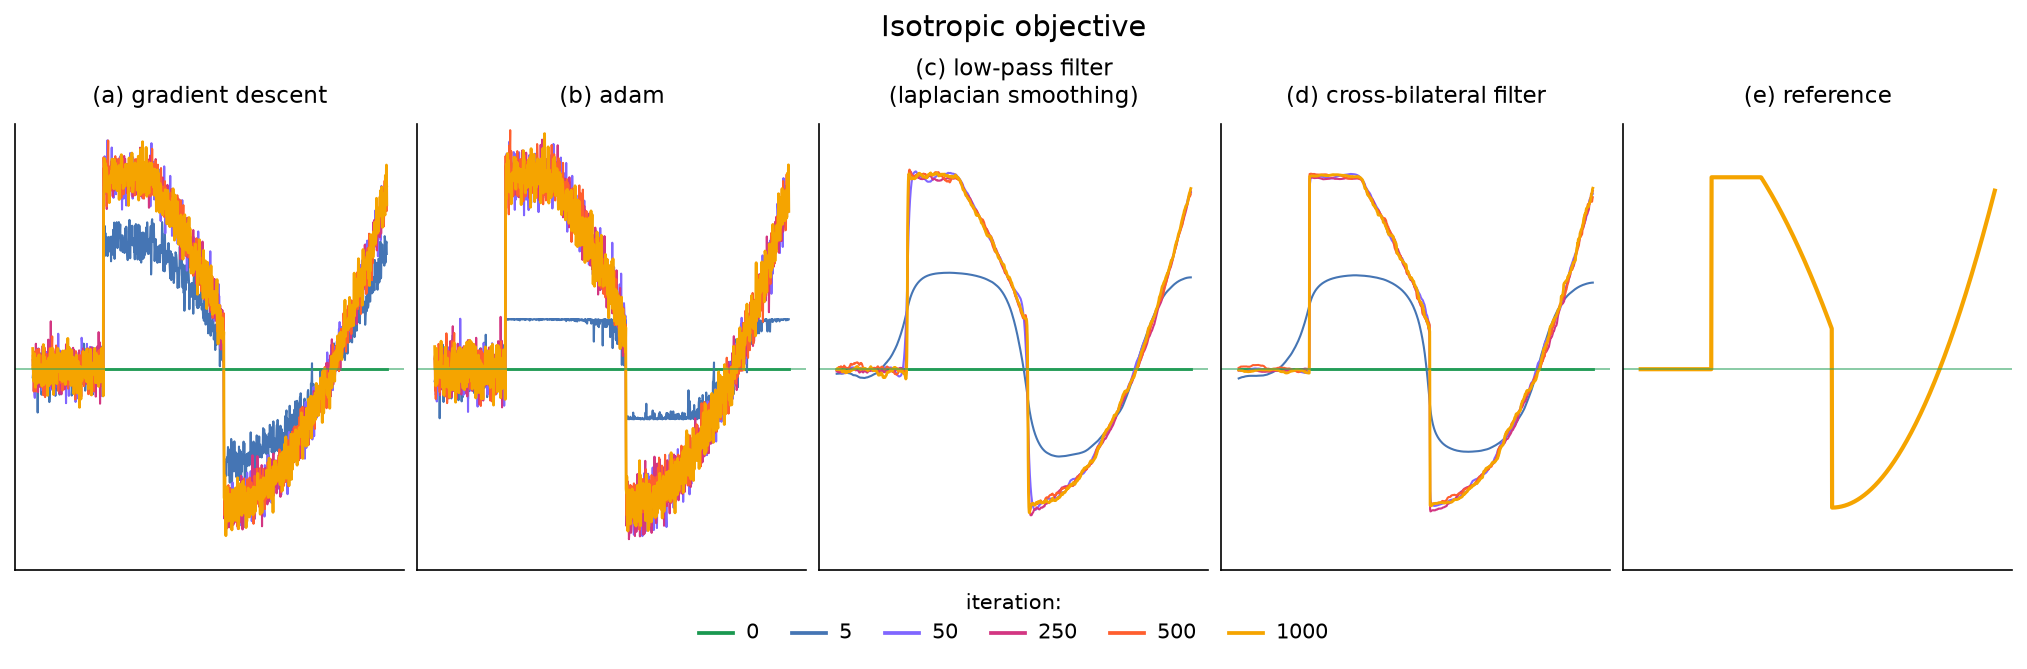

In [14]:
size = 1000
iterations = 1000
snapshots = [0, 5, 50, 250, 500, 1000]
noise_std = 0.32

target = make_paper_style_target(size)
theta_start = np.zeros(size)
noise = rng.normal(scale=noise_std, size=(iterations, size))


def noisy_isotropic_gradient(theta, iteration):
    '''gradient of squared error plus zero-mean gaussian noise.'''
    return 2 * (theta - target) + noise[iteration]


laplacian = laplacian_smoothing_filter(strength=800.0)
bilateral = cross_bilateral_filter(sigma_spatial=70.0, sigma_data=0.10)

histories_figure_3 = {
    'gradient descent': run_gradient_descent(theta_start, noisy_isotropic_gradient, 0.10, iterations, snapshots),
    'adam': run_optimizer(adam_optimizer(lr=0.045, b_1=0.2, b_2=0.2), theta_start, noisy_isotropic_gradient, iterations, snapshots),
    'laplacian': run_optimizer(spatiotemporal_optimizer(lr=0.090, filter=laplacian, b_1=0.2, b_2=0.2), theta_start, noisy_isotropic_gradient, iterations, snapshots),
    'cross bilateral': run_optimizer(spatiotemporal_optimizer(lr=0.090, filter=bilateral, b_1=0.2, b_2=0.2), theta_start, noisy_isotropic_gradient, iterations, snapshots),
}

plot_iteration_overlays(histories_figure_3, target, snapshots, 'Isotropic objective');

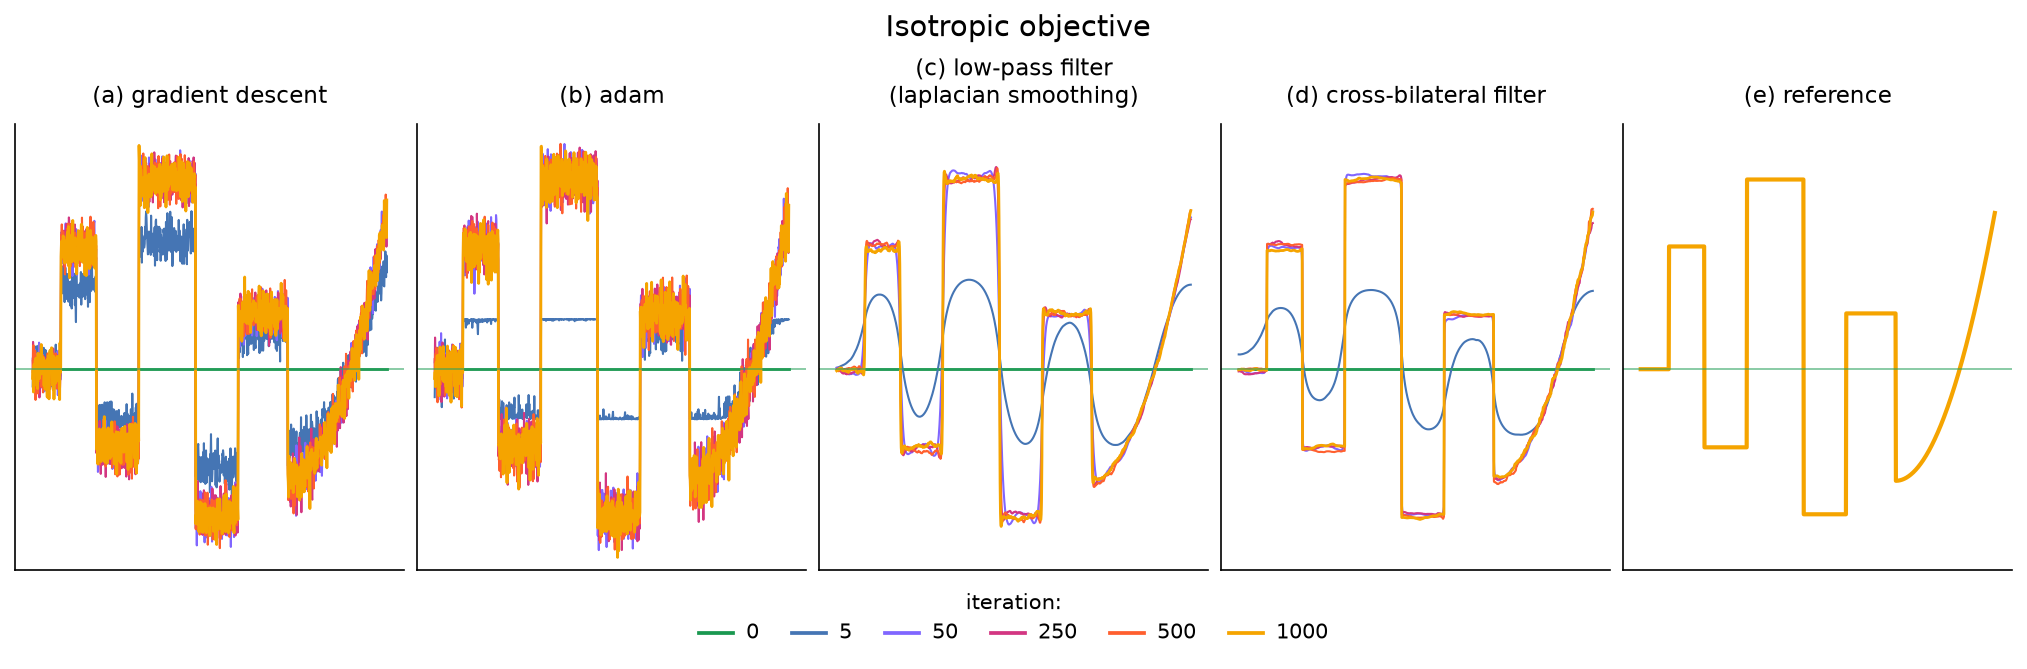

In [16]:
def make_edge_rich_target(size):
    '''make a target with many sharp jumps to stress edge preservation.'''
    x = np.linspace(0, 1, size)
    target = np.zeros(size)

    target[(x >= 0.08) & (x < 0.18)] = 0.55
    target[(x >= 0.18) & (x < 0.30)] = -0.35
    target[(x >= 0.30) & (x < 0.46)] = 0.85
    target[(x >= 0.46) & (x < 0.58)] = -0.65
    target[(x >= 0.58) & (x < 0.72)] = 0.25

    tail = x >= 0.72
    tail_x = (x[tail] - 0.72) / 0.28
    target[tail] = -0.50 + 1.20 * tail_x ** 2

    return target


size = 1000
iterations = 1000
snapshots = [0, 5, 50, 250, 500, 1000]
noise_std = 0.32

target = make_edge_rich_target(size)
theta_start = np.zeros(size)
noise = rng.normal(scale=noise_std, size=(iterations, size))


def noisy_edge_gradient(theta, iteration):
    '''gradient of squared error plus zero-mean gaussian noise.'''
    return 2 * (theta - target) + noise[iteration]


laplacian = laplacian_smoothing_filter(strength=800.0)
bilateral = cross_bilateral_filter(sigma_spatial=70.0, sigma_data=0.10)

histories_edge_rich = {
    'gradient descent': run_gradient_descent(theta_start, noisy_edge_gradient, 0.10, iterations, snapshots),
    'adam': run_optimizer(adam_optimizer(lr=0.045, b_1=0.2, b_2=0.2), theta_start, noisy_edge_gradient, iterations, snapshots),
    'laplacian': run_optimizer(spatiotemporal_optimizer(lr=0.090, filter=laplacian, b_1=0.2, b_2=0.2), theta_start, noisy_edge_gradient, iterations, snapshots),
    'cross bilateral': run_optimizer(spatiotemporal_optimizer(lr=0.090, filter=bilateral, b_1=0.2, b_2=0.2), theta_start, noisy_edge_gradient, iterations, snapshots),
}

plot_iteration_overlays(histories_edge_rich, target, snapshots, ' Isotropic objective');
